In [1]:
# Imports

import matplotlib
import helpers.helper_functions as hf
import mne
import matplotlib.pyplot as plt
import os.path as op

ss = hf.settings_dict()

Use mne automatic methods for artifact detection

loading raw dataset for subject:  0005_3SJ
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/raw_filtered/0005_3SJ-raw.fif...
    Range : 73000 ... 1218999 =     36.500 ...   609.500 secs
Ready.
Reading 0 ... 1145999  =      0.000 ...   573.000 secs...
Reconstructing ECG signal from Gradiometers
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 20000 samples (10.000 s)

Number of ECG events detected : 817 (average pulse 85.54973821989527 / min.)
Not setting metadata
817 matching events found
No baseline correction applied
Using data from preloaded

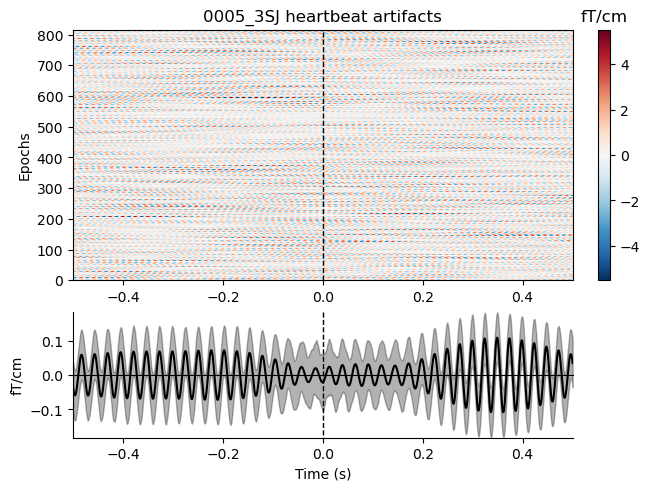

Using EOG channels: EOG003, EOG004
EOG channel index for this subject is: [2 3]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG003 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 273 significant peaks
Number of EOG events detected: 273
Not setting metadata
273 matching events found
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 273 events and 2001 original time points ...
2 bad epochs dropped


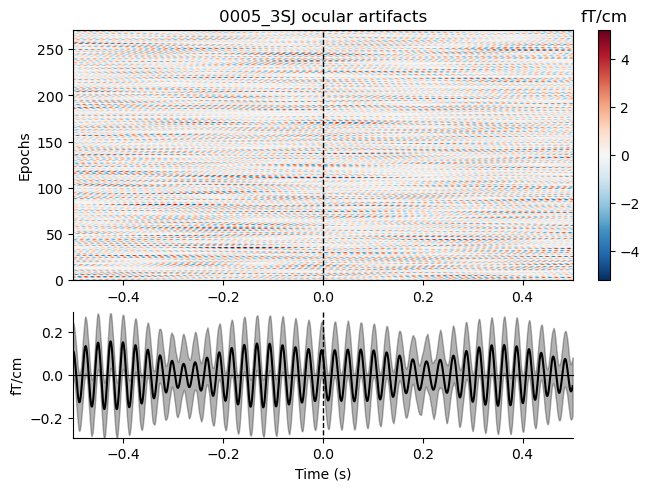

loading raw dataset for subject:  0002_TCZ
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/raw_filtered/0002_TCZ-raw.fif...
    Range : 93000 ... 1274999 =     46.500 ...   637.500 secs
Ready.
Reading 0 ... 1181999  =      0.000 ...   591.000 secs...
Reconstructing ECG signal from Gradiometers
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 20000 samples (10.000 s)

Number of ECG events detected : 863 (average pulse 87.61421319796955 / min.)
Not setting metadata
863 matching events found
No baseline correction applied
Using data from preloaded

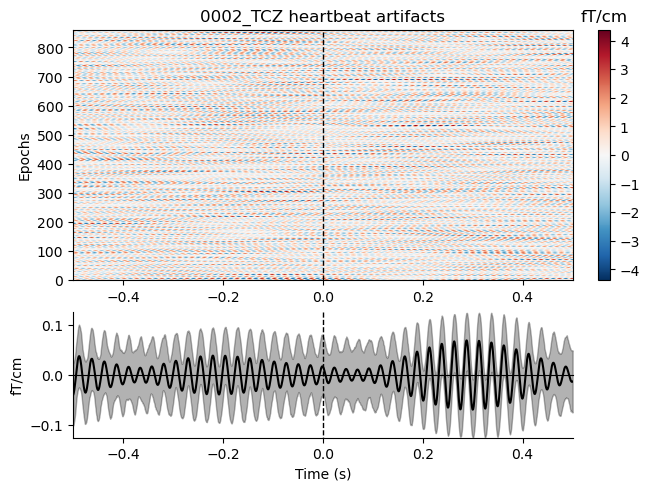

Using EOG channels: EOG003, EOG004
EOG channel index for this subject is: [2 3]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG004 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 54 significant peaks
Number of EOG events detected: 54
Not setting metadata
54 matching events found
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 54 events and 2001 original time points ...
0 bad epochs dropped
Not 

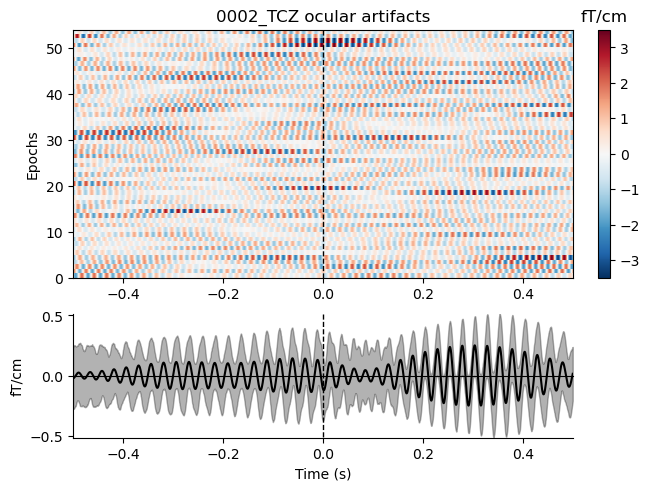

In [3]:
for subject_index in ss['subject_idx_list']:

    subject = ss['subject_id_list'][subject_index]
    print("loading raw dataset for subject: ", subject)

    raw_filtered = hf.load_raw_filtered(subject=subject, preload=True)
    raw_filtered.set_channel_types(mapping={'EMG001': 'emg'})
    raw_filtered.set_channel_types(mapping={'EMG002': 'emg'})
    raw_filtered.set_channel_types(mapping={'EOG003': 'eog'})
    raw_filtered.set_channel_types(mapping={'EOG004': 'eog'})
    raw_filtered.set_channel_types(mapping={'EMG005': 'emg'})
    raw_filtered.pick(picks=['grad', 'stim', 'misc','eeg', 'emg', 'eog'])

    # first check for heart beat artifacts
    ecg_epochs = mne.preprocessing.create_ecg_epochs(raw_filtered)
    ecg_epochs.plot_image(combine="mean", title = subject + " heartbeat artifacts")

    # then for ocular artifacts
    eog_epochs = mne.preprocessing.create_eog_epochs(raw_filtered, baseline=(-0.5, -0.2))
    eog_epochs.plot_image(combine="mean", title = subject + " ocular artifacts")

    del raw_filtered
    del ecg_epochs
    del eog_epochs

Inspect for artifacts with ICA

In [ ]:
#TODO: check for artifacts with ICA

Inspect for artifacts manually

loading raw dataset for subject:  0005_3SJ
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/raw_filtered/0005_3SJ-raw.fif...
    Range : 73000 ... 1218999 =     36.500 ...   609.500 secs
Ready.
Reading 0 ... 1145999  =      0.000 ...   573.000 secs...


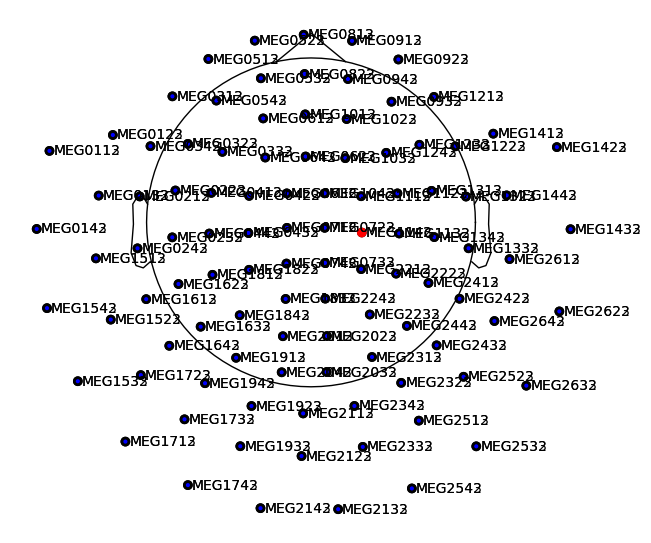

Channels marked as bad:
['MEG1143']
loading raw dataset for subject:  0002_TCZ
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/raw_filtered/0002_TCZ-raw.fif...
    Range : 93000 ... 1274999 =     46.500 ...   637.500 secs
Ready.
Reading 0 ... 1181999  =      0.000 ...   591.000 secs...


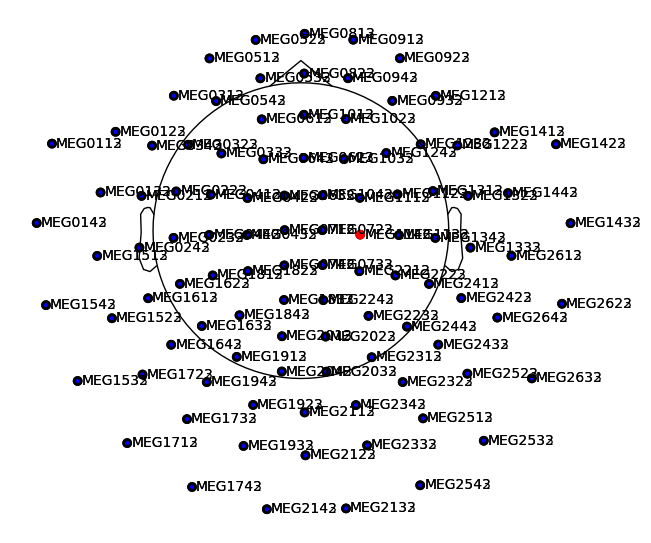

Waiting for Loading-Thread to finish... (max. 10 sec)
Channels marked as bad:
['MEG1143']


In [6]:
%gui qt
mne.viz.set_browser_backend("qt")


first_iter = True

for subject_index in ss['subject_idx_list']:

    subject = ss['subject_id_list'][subject_index]
    print("loading raw dataset for subject: ", subject)

    raw = hf.load_raw_filtered(subject=subject, preload=True)

    if first_iter:
        raw.plot_sensors(kind='topomap', show_names=True, block=True)

    # drop projectors
    ssp_projectors = raw.info["projs"]
    raw.del_proj()

    raw.plot(theme = 'light', block = True, title = subject)

    del raw